# 01 - Week 1 Practical Guided Lab

Each activity follows: **Problem -> Hint -> Solution**.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.stats import skew, f_oneway
np.random.seed(42)
sns.set_theme(style="whitegrid")
iris=load_iris(as_frame=True)
df=iris.frame.copy()
df["species"]=df["target"].map(dict(enumerate(iris.target_names)))
df=df.drop(columns=["target"])


## Task 1 - Inspect dataset
Problem: show `head`, `info`, and `describe`.
Hint: start with `df.head()`.

### Solution


In [2]:
display(df.head())
df.info()
display(df.describe())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Interpretation: clean dataset with mixed variable types.


## Task 2 - Visualize data
Problem: create one histogram and one boxplot.
Hint: `sns.histplot` and `sns.boxplot`.

### Solution


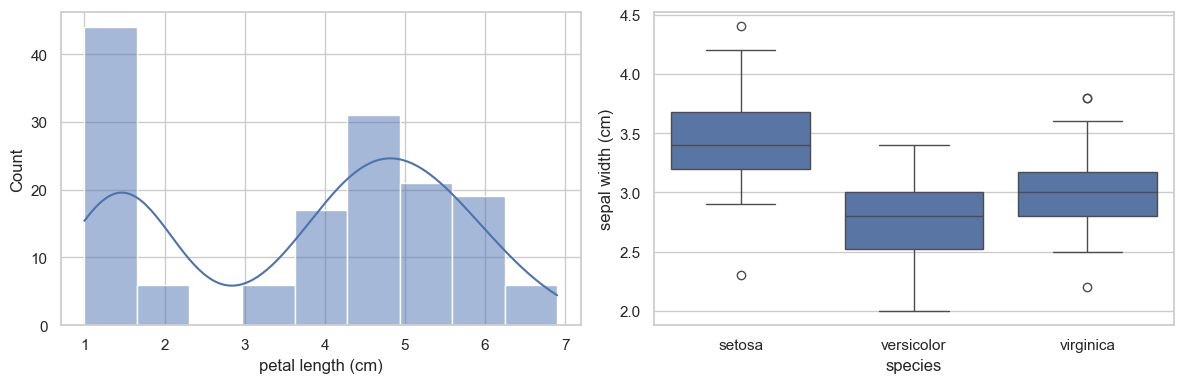

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.histplot(df["petal length (cm)"],kde=True,ax=ax[0])
sns.boxplot(data=df,x="species",y="sepal width (cm)",ax=ax[1])
plt.tight_layout(); plt.show()


## Task 3 - Compute mean, variance, skewness

### Solution


In [4]:
num=df.select_dtypes(include="number").columns
pd.DataFrame({"mean":df[num].mean(),"variance":df[num].var(),"skewness":df[num].apply(lambda x: skew(x,bias=False))})


,mean,variance,skewness
sepal length (cm),5.843333,0.685694,0.314911
sepal width (cm),3.057333,0.189979,0.318966
petal length (cm),3.758000,3.116278,-0.274884
petal width (cm),1.199333,0.581006,-0.102967


## Task 4 - CLT demonstration

### Solution


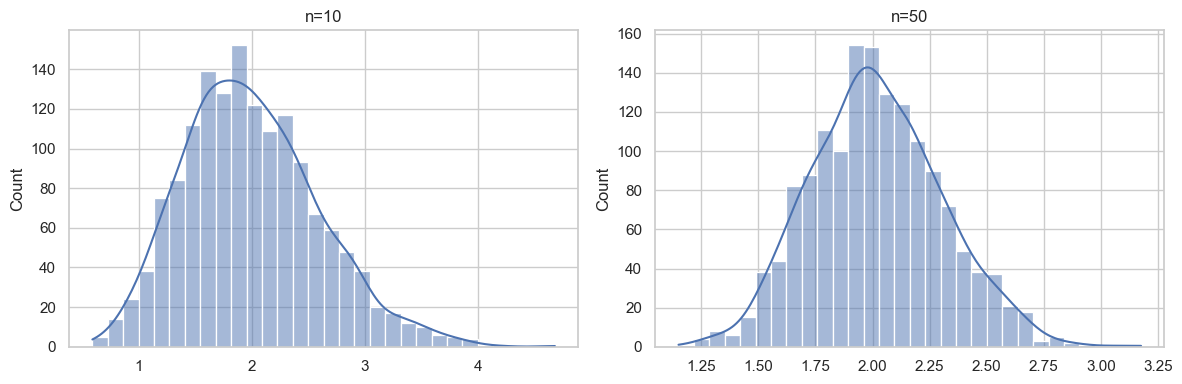

In [5]:
pop=np.random.exponential(scale=2.0,size=100000)
def means(pop,n,reps=1500):
    return np.array([np.random.choice(pop,size=n,replace=True).mean() for _ in range(reps)])
m10=means(pop,10); m50=means(pop,50)
fig,ax=plt.subplots(1,2,figsize=(12,4))
sns.histplot(m10,kde=True,ax=ax[0]); ax[0].set_title("n=10")
sns.histplot(m50,kde=True,ax=ax[1]); ax[1].set_title("n=50")
plt.tight_layout(); plt.show()


Interpretation: larger n yields tighter, more normal sample-mean distribution.


## Task 5 - ANOVA

### Solution


In [6]:
s=df[df["species"]=="setosa"]["petal length (cm)"]
v=df[df["species"]=="versicolor"]["petal length (cm)"]
vi=df[df["species"]=="virginica"]["petal length (cm)"]
F,p=f_oneway(s,v,vi)
print(F,p)
print("Reject H0" if p<0.05 else "Fail to reject H0")


1180.161182252981 2.8567766109615584e-91
Reject H0


## Key Takeaway
A good workflow is: inspect -> summarize -> visualize -> test -> interpret.
